### 0. 데이터 로딩
- ex02에서 저장한 actor별 action pickle 파일들을 불러와서 병합

In [4]:
import pandas as pd
import numpy as np
import ast

# ex02에서 저장한 pickle 파일 수 (actor 수와 동일)
NUM_ACTORS = 2  # ← cluster_sbert의 고유값 수로 변경

df_list = []
for i in range(1,NUM_ACTORS):
    df_list.append(pd.read_pickle(f"/content/cluster_df_1_action (1).pkl"))

print(f"{len(df_list)}개 actor 파일 로딩 완료")

1개 actor 파일 로딩 완료


In [5]:
# 하나의 데이터프레임으로 병합
df = pd.concat(df_list, axis=0)
df.reset_index(drop=True, inplace=True)

print("병합 후 shape:", df.shape)
df.head()

병합 후 shape: (40549, 6)


,doc_idx,text,tokens,tokens_str,cluster_sbert,action_cluster
0,0,무엇이든지물어보세요신발보관 어떻게 하세요? 안녕하세요 곧 미국으로 1년 주재원 생활...,"[신발, 보관, 안녕, 미국, 주재원, 생활, 떠나, 가져가, 물건, 신발, 보관,...",신발 보관 안녕 미국 주재원 생활 떠나 가져가 물건 신발 보관 적히 선박 이사 가져...,1,3
1,1,자유일상이야기신발 보관은 이제 이렇게! Vsyoy 접이식 신발 보관함 신발 정리에 ...,"[자유, 일상, 이야기, 신발, 보관, 접이식, 신발, 보관, 신발, 정리, 고민,...",자유 일상 이야기 신발 보관 접이식 신발 보관 신발 정리 고민 처음 불편 신발 어지...,1,3
2,2,"묻고답하기말머리Q ,제목내용요약,삭제X말머리Q부아텅 폭포에서 신발 보관? 어떻게 하...","[머리, 제목, 내용, 요약, 삭제, 말머리, 부아텅, 폭포, 신발, 보관, 안녕,...",머리 제목 내용 요약 삭제 말머리 부아텅 폭포 신발 보관 안녕 모레 부아텅 폭포 후...,1,3
3,3,신발 톡혹시 트렁크에 신발 보관하신 분 계신가요 저는 매번 가지고 나오기 싫어서 그...,"[신발, 트렁크, 신발, 보관, 계시, 가지, 나오, 트렁크, 레이싱, 보관, 여기...",신발 트렁크 신발 보관 계시 가지 나오 트렁크 레이싱 보관 여기저기 트렁크 보관 물...,1,3
4,4,FREE다들 신발 보관 어캐하심들? 조던이나 이런거 오래보관하려면 어캐관리함?,"[신발, 보관, 어캐, 조던, 보관, 어캐, 관리]",신발 보관 어캐 조던 보관 어캐 관리,1,3


In [6]:
# tokens 컬럼이 문자열인 경우 리스트로 변환
if isinstance(df['tokens'].iloc[0], str):
    df['tokens'] = df['tokens'].apply(ast.literal_eval)

# actor 컬럼명 통일 (cluster_sbert → cluster)
if 'cluster_sbert' in df.columns and 'cluster' not in df.columns:
    df = df.rename(columns={'cluster_sbert': 'cluster'})

print("컬럼 목록:", df.columns.tolist())
df.head()

컬럼 목록: ['doc_idx', 'text', 'tokens', 'tokens_str', 'cluster', 'action_cluster']


,doc_idx,text,tokens,tokens_str,cluster,action_cluster
0,0,무엇이든지물어보세요신발보관 어떻게 하세요? 안녕하세요 곧 미국으로 1년 주재원 생활...,"[신발, 보관, 안녕, 미국, 주재원, 생활, 떠나, 가져가, 물건, 신발, 보관,...",신발 보관 안녕 미국 주재원 생활 떠나 가져가 물건 신발 보관 적히 선박 이사 가져...,1,3
1,1,자유일상이야기신발 보관은 이제 이렇게! Vsyoy 접이식 신발 보관함 신발 정리에 ...,"[자유, 일상, 이야기, 신발, 보관, 접이식, 신발, 보관, 신발, 정리, 고민,...",자유 일상 이야기 신발 보관 접이식 신발 보관 신발 정리 고민 처음 불편 신발 어지...,1,3
2,2,"묻고답하기말머리Q ,제목내용요약,삭제X말머리Q부아텅 폭포에서 신발 보관? 어떻게 하...","[머리, 제목, 내용, 요약, 삭제, 말머리, 부아텅, 폭포, 신발, 보관, 안녕,...",머리 제목 내용 요약 삭제 말머리 부아텅 폭포 신발 보관 안녕 모레 부아텅 폭포 후...,1,3
3,3,신발 톡혹시 트렁크에 신발 보관하신 분 계신가요 저는 매번 가지고 나오기 싫어서 그...,"[신발, 트렁크, 신발, 보관, 계시, 가지, 나오, 트렁크, 레이싱, 보관, 여기...",신발 트렁크 신발 보관 계시 가지 나오 트렁크 레이싱 보관 여기저기 트렁크 보관 물...,1,3
4,4,FREE다들 신발 보관 어캐하심들? 조던이나 이런거 오래보관하려면 어캐관리함?,"[신발, 보관, 어캐, 조던, 보관, 어캐, 관리]",신발 보관 어캐 조던 보관 어캐 관리,1,3


### 1. Satisfaction (만족도)
- HuggingFace `monologg/koelectra-base-finetuned-sentiment` 모델로 감성분석
- KNU 감성사전 방식(단어 매칭)과 달리 **문장 전체 문맥**을 이해하여 긍정/부정 분류
- 긍정 확률(0~1)을 감성점수로 사용 → 0~10으로 정규화

#### 1.1 KoELECTRA 모델 로딩
- 모델: `monologg/koelectra-base-finetuned-sentiment`
- 라벨: `positive`(긍정) / `negative`(부정)
- 입력: 원문 텍스트(`text` 컬럼) — 토큰이 아닌 원문 문장 사용
- 512 토큰 초과 시 자동 truncation 처리

In [7]:
!pip install transformers torch -q

In [8]:
from transformers import pipeline

MODEL_NAME = "monologg/koelectra-base-finetuned-sentiment"

# GPU 사용 가능 여부 자동 감지
import torch
device = 0 if torch.cuda.is_available() else -1
print("사용 디바이스:", "GPU" if device == 0 else "CPU")

sentiment_pipeline = pipeline(
    "text-classification",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    device=device
)

# 동작 테스트
print("긍정 테스트:", sentiment_pipeline("오늘 정말 기분이 좋아요!"))
print("부정 테스트:", sentiment_pipeline("너무 힘들고 지쳐서 못하겠어요."))

사용 디바이스: GPU


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/441M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/441M [00:00<?, ?B/s]

ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-base-finetuned-sentiment
Key                        | Status     | 
---------------------------+------------+-
classifier.bias            | UNEXPECTED | 
classifier.weight          | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

긍정 테스트: [{'label': 'positive', 'score': 0.5678008794784546}]
부정 테스트: [{'label': 'negative', 'score': 0.5036211013793945}]


#### 1.2 전체 문서 감성분석 (배치 처리)
- `text` 컬럼(원문 문장)을 모델에 입력
- 배치 처리로 속도 향상

In [9]:
from tqdm import tqdm

BATCH_SIZE = 32  # ← GPU 메모리에 따라 조절 (CPU면 16~32 권장)

texts = df['text'].fillna('').tolist()
raw_results = []

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="감성분석 진행중"):
    batch = texts[i:i + BATCH_SIZE]
    results = sentiment_pipeline(
        batch,
        truncation=True,
        max_length=512
    )
    raw_results.extend(results)

print(f"\n분석 완료: {len(raw_results)}건")
print("결과 샘플:", raw_results[:3])

감성분석 진행중: 100%|██████████| 1268/1268 [11:05<00:00,  1.91it/s]


분석 완료: 40549건
결과 샘플: [{'label': 'positive', 'score': 0.5039746761322021}, {'label': 'positive', 'score': 0.5504938364028931}, {'label': 'positive', 'score': 0.502805769443512}]


#### 1.3 긍정 확률을 감성점수로 변환
- `positive` 라벨이면 score 그대로 사용
- `negative` 라벨이면 `1 - score`로 변환
- 결과: 0(완전 부정) ~ 1(완전 긍정)

In [11]:
def extract_positive_score(result):
    """모델 출력에서 긍정 확률 추출"""
    label = result['label'].lower()
    score = result['score']
    if label in ('positive', '1', 'pos'):
        return score
    else:  # negative, 0, neg
        return 1 - score

sentiment_scores = [extract_positive_score(r) for r in raw_results]

df['sentiment_score'] = sentiment_scores

print("감성점수 기초 통계 (긍정 확률 0~1):")
print(df['sentiment_score'].describe())
df[['text', 'cluster', 'action_cluster', 'sentiment_score']].head(10)

감성점수 기초 통계 (긍정 확률 0~1):
count    40549.000000
mean         0.513928
std          0.019993
min          0.466486
25%          0.498885
50%          0.506937
75%          0.526786
max          0.595294
Name: sentiment_score, dtype: float64


,text,cluster,action_cluster,sentiment_score
0,무엇이든지물어보세요신발보관 어떻게 하세요? 안녕하세요 곧 미국으로 1년 주재원 생활...,1,3,0.503975
1,자유일상이야기신발 보관은 이제 이렇게! Vsyoy 접이식 신발 보관함 신발 정리에 ...,1,3,0.550494
2,"묻고답하기말머리Q ,제목내용요약,삭제X말머리Q부아텅 폭포에서 신발 보관? 어떻게 하...",1,3,0.502806
3,신발 톡혹시 트렁크에 신발 보관하신 분 계신가요 저는 매번 가지고 나오기 싫어서 그...,1,3,0.504038
4,FREE다들 신발 보관 어캐하심들? 조던이나 이런거 오래보관하려면 어캐관리함?,1,3,0.493965
5,"자유일상이야기신발 정리함으로 깔끔한 공간 만들기 여러분, 신발 정리하는 거 어렵지 ...",1,3,0.567796
6,신발 궁금증 물어보세요질문이.있습니다..신발 보관 관련 지금 구매하려고 하는데 신발...,1,3,0.492042
7,생활의 지혜 방한용 신발 보관하는 방법 겨우내 눈비염화칼슘과 사투를 벌였던 방한용 ...,1,2,0.504399
8,"자유게시판진정한 럭셔리, 레디박스 아크릴 신발보관 케이스 혹시 신발이 많아 보관할 ...",1,3,0.556196
9,QA질문답변차량 내부 헬멧 보관 어떻게 하시나요? 안녕하세요. 차량 헬멧 보관을 어...,1,3,0.501401


#### 1.4 Actor별 Action 감성점수 집계 (평균)

In [12]:
action_sentiments = {}

for actor in sorted(df['cluster'].unique()):
    actor_df = df[df['cluster'] == actor]
    for action in sorted(actor_df['action_cluster'].unique()):
        action_df = actor_df[actor_df['action_cluster'] == action]
        action_sentiment_avg = np.mean(action_df['sentiment_score'])
        key = f"Actor{actor}_Action{action}"
        action_sentiments[key] = action_sentiment_avg
        print(f"  {key}: {action_sentiment_avg:.4f} ({len(action_df)}건)")

print("\n집계 완료")

  Actor1_Action1: 0.5140 (7445건)
  Actor1_Action2: 0.5166 (8063건)
  Actor1_Action3: 0.5128 (17284건)
  Actor1_Action4: 0.5157 (2604건)
  Actor1_Action5: 0.5127 (4542건)
  Actor1_Action6: 0.5126 (611건)

집계 완료


#### 1.5 감성점수 정규화 (0~10 스케일링)

In [13]:
!pip install new_value_analysis -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 8.9 MB/s eta 0:00:00


In [14]:
from new_value_analysis.opportunity_area_analysis import minmax_scale_scores

scaled_scores = minmax_scale_scores(action_sentiments, feature_range=(0, 10))

for key, score in zip(action_sentiments.keys(), scaled_scores):
    action_sentiments[key] = score

print("정규화 후 감성점수 (0~10):")
action_sentiments

정규화 후 감성점수 (0~10):


{'Actor1_Action1': 3.3713,
 'Actor1_Action2': 10.0,
 'Actor1_Action3': 0.3944,
 'Actor1_Action4': 7.6424,
 'Actor1_Action5': 0.3043,
 'Actor1_Action6': 0.0}

In [15]:
# 만족도 데이터프레임 생성 및 저장
satisfaction_df = pd.DataFrame(action_sentiments.items(), columns=['Action', 'satisfaction'])
satisfaction_df.to_pickle('./satisfaction_df.pkl')
print("저장 완료: satisfaction_df.pkl")
satisfaction_df

저장 완료: satisfaction_df.pkl


,Action,satisfaction
0,Actor1_Action1,3.3713
1,Actor1_Action2,10.0000
2,Actor1_Action3,0.3944
3,Actor1_Action4,7.6424
4,Actor1_Action5,0.3043
5,Actor1_Action6,0.0000


### 2. Importance (중요도)
- 문서 언급 빈도 기반으로 중요도 측정
- 1~10 범위로 정규화

In [16]:
# 각 문서에 Actor_Action 라벨 부여
actor_action_labels = [
    f"Actor{actor}_Action{action}"
    for actor, action in zip(df['cluster'], df['action_cluster'])
]

s = pd.Series(actor_action_labels)
total_count = s.shape[0]

importances = s.value_counts() / total_count
print("Actor-Action별 언급 비율:")
importances

Actor-Action별 언급 비율:


,count
Actor1_Action3,0.426250
Actor1_Action2,0.198846
Actor1_Action1,0.183605
Actor1_Action5,0.112013
Actor1_Action4,0.064219
Actor1_Action6,0.015068


In [17]:
scaled_importances = minmax_scale_scores(importances, feature_range=(1, 10))

importance_df = importances.reset_index()
importance_df.columns = ['Action', 'count_ratio']
importance_df['importance'] = scaled_importances

print("정규화 후 중요도 (1~10):")
importance_df

정규화 후 중요도 (1~10):


,Action,count_ratio,importance
0,Actor1_Action3,0.426250,10.0000
1,Actor1_Action2,0.198846,5.0226
2,Actor1_Action1,0.183605,4.6890
3,Actor1_Action5,0.112013,3.1219
4,Actor1_Action4,0.064219,2.0758
5,Actor1_Action6,0.015068,1.0000


### 3. 만족도 + 중요도 병합 및 Opportunity Score
- 공식: `중요도 + max(중요도 - 만족도, 0)`

In [18]:
satisfaction_df = satisfaction_df.set_index('Action')
importance_df = importance_df.set_index('Action')

satisfaction_df['importance'] = importance_df['importance']
DCX_summary = satisfaction_df.copy()

print("DCX Summary:")
DCX_summary

DCX Summary:


,satisfaction,importance
Action,,
Actor1_Action1,3.3713,4.6890
Actor1_Action2,10.0000,5.0226
Actor1_Action3,0.3944,10.0000
Actor1_Action4,7.6424,2.0758
Actor1_Action5,0.3043,3.1219
Actor1_Action6,0.0000,1.0000


In [19]:
def opportunity_score(sat, imp):
    """기회점수 = 중요도 + max(중요도 - 만족도, 0)"""
    return imp + max(imp - sat, 0)

DCX_summary['opportunity'] = [
    opportunity_score(s, i)
    for s, i in zip(DCX_summary['satisfaction'], DCX_summary['importance'])
]

DCX_summary.to_csv('./opportunity.csv')
print("저장 완료: opportunity.csv")
DCX_summary

저장 완료: opportunity.csv


,satisfaction,importance,opportunity
Action,,,
Actor1_Action1,3.3713,4.6890,6.0067
Actor1_Action2,10.0000,5.0226,5.0226
Actor1_Action3,0.3944,10.0000,19.6056
Actor1_Action4,7.6424,2.0758,2.0758
Actor1_Action5,0.3043,3.1219,5.9395
Actor1_Action6,0.0000,1.0000,2.0000


### 4. 기회영역 시각화

In [20]:
from new_value_analysis.opportunity_area_analysis import plot_opportunity_area, OpportunityPlotConfig

DCX_summary = DCX_summary.reset_index()
print("컬럼 목록:", DCX_summary.columns.tolist())

컬럼 목록: ['Action', 'satisfaction', 'importance', 'opportunity']


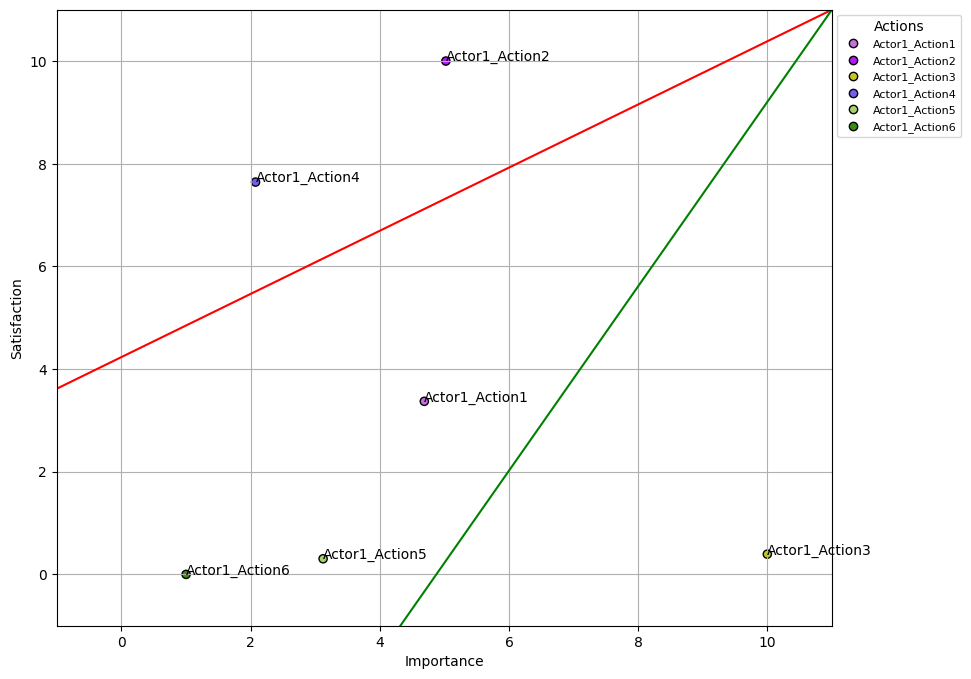

시각화 저장 완료: Opportunity_area.png


In [21]:
cfg = OpportunityPlotConfig(save_path='./Opportunity_area.png',random_seed=42,xlim=(-1,11),ylim=(-1,11))

plot_opportunity_area(DCX_summary.dropna(), cfg)
print("시각화 저장 완료: Opportunity_area.png")